## 4.1 Setup and output paths

This section loads the libraries used for splitting, preprocessing, modeling, and reporting, points the notebook to the cleaned dataset, and prepares the output folders so subsequent sections can write CSVs and figures without further setup.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, f_oneway

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit,
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="talk")

RANDOM_STATE = 42

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATASET_PATH = ROOT / "data" / "processed" / "dataset_final.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
FOLDS_DIR = PROCESSED_DIR / "ml_stratified_5folds"
OUTPUTS_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
for output_directory in (FIGURES_DIR, TABLES_DIR, FOLDS_DIR):
    output_directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Dataset path: {DATASET_PATH.relative_to(ROOT)}")
print(f"Folds directory: {FOLDS_DIR.relative_to(ROOT)}")
print(f"Tables directory: {TABLES_DIR.relative_to(ROOT)}")
print(f"Figures directory: {FIGURES_DIR.relative_to(ROOT)}")

Project root: /Users/berenaydogan/Documents/4.2/DSA210/Project/DSA210-Project
Dataset path: data/processed/dataset_final.csv
Folds directory: data/processed/ml_stratified_5folds
Tables directory: outputs/tables
Figures directory: outputs/figures


In [2]:
assert DATASET_PATH.exists(), "Run data_collection.ipynb first so data/processed/dataset_final.csv exists."

date_columns = ["service_date", "scheduled_arrival", "scheduled_arrival_date", "weather_time"]
df = pd.read_csv(DATASET_PATH, parse_dates=date_columns)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 90,818
Columns: 21


,service_date,season,scheduled_arrival,scheduled_arrival_date,delay_minutes,delayed,scheduled_arrival_hour,scheduled_arrival_weekday,scheduled_arrival_weekday_name,scheduled_arrival_month,...,stop_name,train_type,line_name,operator,weather_time,temperature_2m,precipitation,snowfall,wind_speed_10m,weather_matched
0,2025-01-01,Winter,2025-01-01 01:25:00,2025-01-01,-0.200000,0,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
1,2025-01-01,Winter,2025-01-01 01:27:00,2025-01-01,1.000000,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
2,2025-01-01,Winter,2025-01-01 01:34:00,2025-01-01,1.300000,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
3,2025-01-01,Winter,2025-01-01 01:35:00,2025-01-01,-0.650000,0,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
4,2025-01-01,Winter,2025-01-01 01:52:00,2025-01-01,0.183333,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True


## 4.2 Stratified train/test split and 5-fold cross-validation partition

This section produces the splits the rest of the notebook depends on. The 80/20 split is stratified by the joint `(season, delayed)` key so that each season and each delay class is represented in train and test in the same proportion as the full dataset. The same stratification key is also used to build five folds inside the training set.

In [3]:
# Candidate input features mirror the list locked in data_collection.ipynb. The target is the binary delayed indicator.
CANDIDATE_FEATURES: list[str] = [
    "scheduled_arrival_hour",
    "scheduled_arrival_weekday_name",
    "season",
    "is_weekend",
    "stop_name",
    "train_type",
    "line_name",
    "operator",
    "temperature_2m",
    "precipitation",
    "snowfall",
    "wind_speed_10m",
]
TARGET: str = "delayed"

# Combine season and delayed into a single key so a single argument controls stratification.
stratify_key = df["season"].astype(str) + "_" + df[TARGET].astype(str)
print("Stratification strata and counts:")
display(stratify_key.value_counts().rename_axis("season_delayed").to_frame("n_rows"))

Stratification strata and counts:


,n_rows
season_delayed,
Winter_0,13288
Spring_0,13159
Autumn_0,12677
Autumn_1,12319
Winter_1,11764
Spring_1,11610
Summer_0,8636
Summer_1,7365


In [4]:
# StratifiedShuffleSplit gives a single 80/20 partition while preserving proportions.
split_iterator = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_indices, test_indices = next(split_iterator.split(df, stratify_key))

train_df = df.iloc[train_indices].reset_index(drop=True)
test_df = df.iloc[test_indices].reset_index(drop=True)

train_csv_path = PROCESSED_DIR / "ml_stratified_80_20_train.csv"
test_csv_path = PROCESSED_DIR / "ml_stratified_80_20_test.csv"
train_df.to_csv(train_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"Train rows: {len(train_df):,}")
print(f"Test rows : {len(test_df):,}")
print(f"Train delay rate: {train_df[TARGET].mean():.4f}")
print(f"Test  delay rate: {test_df[TARGET].mean():.4f}")
print(f"Saved train split to {train_csv_path.relative_to(ROOT)}")
print(f"Saved test split to {test_csv_path.relative_to(ROOT)}")

Train rows: 72,654
Test rows : 18,164
Train delay rate: 0.4741
Test  delay rate: 0.4741
Saved train split to data/processed/ml_stratified_80_20_train.csv
Saved test split to data/processed/ml_stratified_80_20_test.csv


In [5]:
# Build the same key on the training set and stratify five folds.
train_stratify_key = train_df["season"].astype(str) + "_" + train_df[TARGET].astype(str)
fold_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# fold_id stores each row's validation fold (0..4)
fold_id = np.full(len(train_df), -1, dtype=int)
for fold_index, (fit_indices, validation_indices) in enumerate(
    fold_splitter.split(train_df, train_stratify_key), start=1
):
    fit_csv = FOLDS_DIR / f"fold_{fold_index:02d}_train.csv"
    validation_csv = FOLDS_DIR / f"fold_{fold_index:02d}_validation.csv"
    train_df.iloc[fit_indices].to_csv(fit_csv, index=False)
    train_df.iloc[validation_indices].to_csv(validation_csv, index=False)
    fold_id[validation_indices] = fold_index - 1

assert (fold_id >= 0).all(), "Every training row should have been assigned to exactly one validation fold."
print(f"Saved fold CSVs to {FOLDS_DIR.relative_to(ROOT)}")
print("Validation rows per fold:")
display(pd.Series(fold_id).value_counts().sort_index().rename_axis("fold_index").to_frame("n_validation_rows"))

Saved fold CSVs to data/processed/ml_stratified_5folds
Validation rows per fold:


,n_validation_rows
fold_index,
0,14531
1,14531
2,14531
3,14531
4,14530


In [6]:
def summarize_partition(
    partition_label: str,
    partition_frame: pd.DataFrame,
) -> pd.DataFrame:
    """Return per-(season, delayed) row counts and within partition shares.

    Args:
        partition_label: Train/test to write into the resulting frame's "partition" column.
        partition_frame: A DataFrame containing the rows of this partition.

    Returns:
        A long-format DataFrame with columns "partition", "season",
        "delayed", "n_rows" and "share_within_partition".
    """
    grouped = (
        partition_frame.groupby(["season", TARGET], observed=False)
        .size()
        .rename("n_rows")
        .reset_index()
    )
    grouped["partition"] = partition_label
    grouped["share_within_partition"] = grouped["n_rows"] / grouped["n_rows"].sum()
    return grouped[["partition", "season", TARGET, "n_rows", "share_within_partition"]]


summary_rows: list[pd.DataFrame] = [
    summarize_partition("train", train_df),
    summarize_partition("test", test_df),
]
for fold_index in range(1, 6):
    fit_path = FOLDS_DIR / f"fold_{fold_index:02d}_train.csv"
    validation_path = FOLDS_DIR / f"fold_{fold_index:02d}_validation.csv"
    summary_rows.append(summarize_partition(f"fold_{fold_index:02d}_train", pd.read_csv(fit_path)))
    summary_rows.append(
        summarize_partition(f"fold_{fold_index:02d}_validation", pd.read_csv(validation_path))
    )

split_summary = pd.concat(summary_rows, ignore_index=True)
split_summary_path = TABLES_DIR / "ml_split_summary.csv"
split_summary.to_csv(split_summary_path, index=False)
print(f"Saved split summary to {split_summary_path.relative_to(ROOT)}")
display(split_summary.head(16))

Saved split summary to outputs/tables/ml_split_summary.csv


,partition,season,delayed,n_rows,share_within_partition
0,train,Autumn,0,10142,0.139593
1,train,Autumn,1,9855,0.135643
2,train,Spring,0,10527,0.144892
3,train,Spring,1,9288,0.127839
4,train,Summer,0,6909,0.095095
5,train,Summer,1,5892,0.081097
6,train,Winter,0,10630,0.146310
7,train,Winter,1,9411,0.129532
8,test,Autumn,0,2535,0.139562
9,test,Autumn,1,2464,0.135653


Saved figure to outputs/figures/ml_split_distribution.png


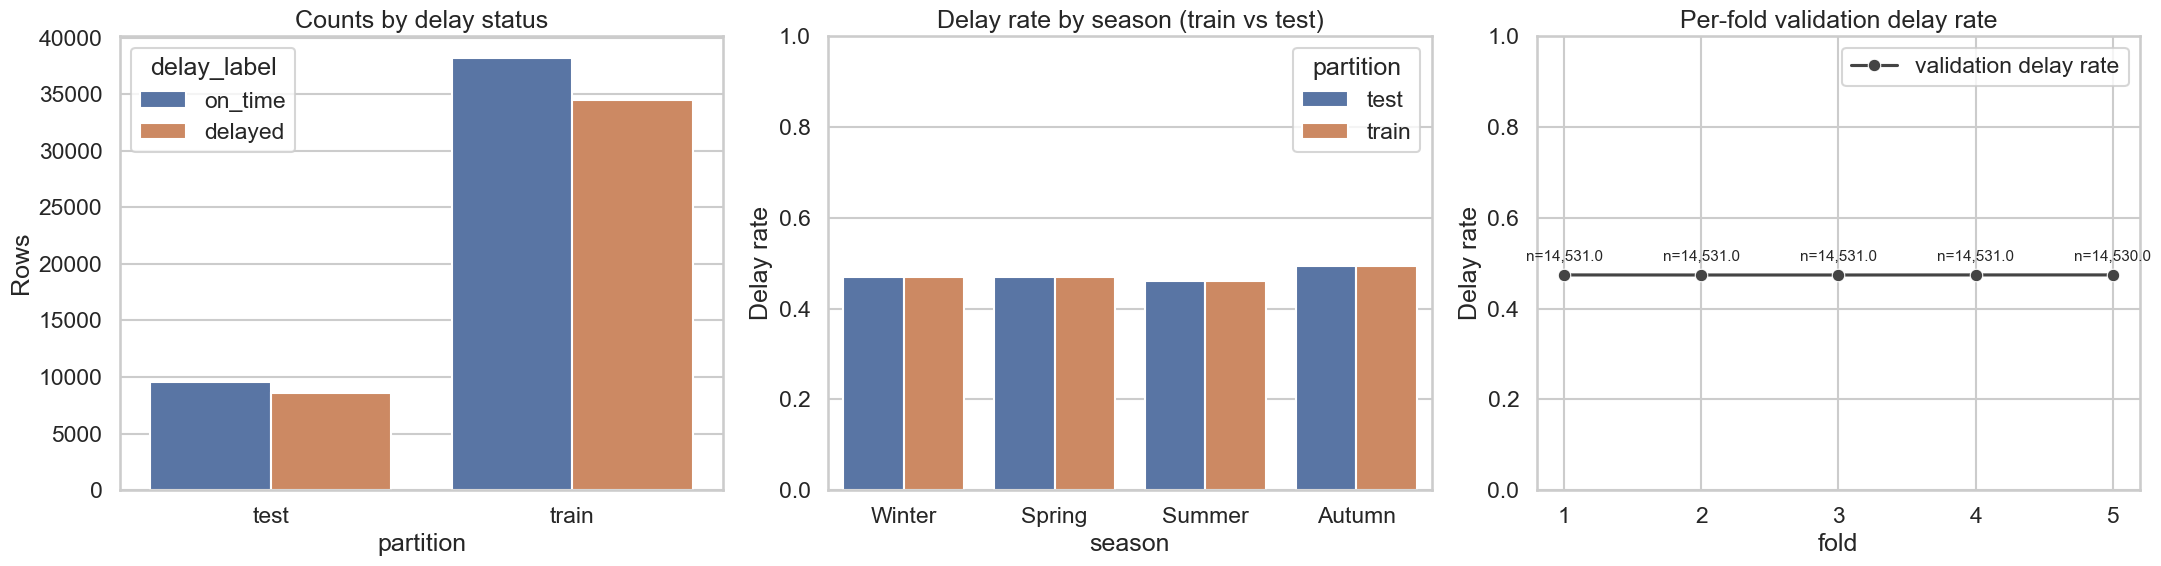

In [7]:
# Visually display counts by delay status, delay rates in train vs test per season, and delay rates per fold.
fold_validation_rows = pd.DataFrame(
    {
        "fold": np.arange(1, 6),
        "n_validation_rows": [int((fold_id == k).sum()) for k in range(5)],
        "validation_delay_rate": [
            float(train_df.loc[fold_id == k, TARGET].mean()) for k in range(5)
        ],
    }
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_delay_rate = (
    pd.concat(
        [
            train_df.assign(partition="train"),
            test_df.assign(partition="test"),
        ]
    )
    .groupby(["partition", "season"], observed=False)[TARGET]
    .mean()
    .reset_index(name="delay_rate")
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

delay_counts = (
    pd.concat(
        [
            train_df.assign(partition="train"),
            test_df.assign(partition="test"),
        ]
    )
    .groupby(["partition", TARGET])
    .size()
    .reset_index(name="n_rows")
)
delay_counts["delay_label"] = delay_counts[TARGET].map({0: "on_time", 1: "delayed"})
sns.barplot(
    data=delay_counts,
    x="partition",
    y="n_rows",
    hue="delay_label",
    ax=axes[0],
)
axes[0].set_title("Counts by delay status")
axes[0].set_ylabel("Rows")

sns.barplot(
    data=season_delay_rate,
    x="season",
    y="delay_rate",
    hue="partition",
    order=season_order,
    ax=axes[1],
)
axes[1].set_title("Delay rate by season (train vs test)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Delay rate")

sns.lineplot(
    data=fold_validation_rows,
    x="fold",
    y="validation_delay_rate",
    marker="o",
    ax=axes[2],
    color="#444444",
    label="validation delay rate",
)
axes[2].set_ylim(0, 1)
axes[2].set_title("Per-fold validation delay rate")
axes[2].set_ylabel("Delay rate")
axes[2].set_xticks(fold_validation_rows["fold"])
for _, row in fold_validation_rows.iterrows():
    axes[2].annotate(
        f"n={row['n_validation_rows']:,}",
        xy=(row["fold"], row["validation_delay_rate"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=11,
    )

fig.tight_layout()
split_distribution_path = FIGURES_DIR / "ml_split_distribution.png"
fig.savefig(split_distribution_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {split_distribution_path.relative_to(ROOT)}")
plt.show()

Train and test row counts come out close to the expected 80/20 of 90,818, and the delay rates per season match between train and test, which confirms that stratification preserved the distribution. 

Validation row counts across the five folds are uniform and the delay rates per fold stay around the overall training rate, so cross validation will not be skewed by an outlier fold.

## 4.3 Class balance check and tuning metric choice

This section checks if classes are balanced and decides on a tuning metric accourdingly. If the training set's delayed-class share lies within ±5 percentage points of 50%, the problem is balanced and accuracy can be used as a reliable tuning metric. Otherwise, we tune on the delayed-class F1 so the rarer outcome is not ignored.

In [8]:
BALANCE_TOLERANCE = 0.05  # Distance from 0.5 within which we treat the problem as class-balanced.
positive_share = float(train_df[TARGET].mean())
is_balanced = abs(positive_share - 0.5) <= BALANCE_TOLERANCE
TUNING_METRIC = "accuracy" if is_balanced else "f1"
TUNING_METRIC_LABEL = "accuracy" if TUNING_METRIC == "accuracy" else "F1 (delayed class)"

print(f"Training delayed share: {positive_share:.4f}")
print(f"Balanced (|p - 0.5| <= {BALANCE_TOLERANCE})? {is_balanced}")
print(f"Tuning metric: {TUNING_METRIC}")

Training delayed share: 0.4741
Balanced (|p - 0.5| <= 0.05)? True
Tuning metric: accuracy


## 4.4 Feature selection via hypothesis testing on the training set

This section re-runs the same twelve hypotheses from `hypothesis_testing.ipynb` on the training set only. Arrival-level chi-square tests use the training rows directly. The weather-level ANOVA tests aggregate the training arrivals into one row per `weather_time` so each ANOVA group is built from the training data alone. Features whose underlying tests reject the null at α = 0.05 are kept for modeling; features whose tests do not reject are dropped before preprocessing.

In [9]:
def make_quantile_labels(series: pd.Series, prefix: str) -> pd.Series:
    """Return labelled quartile groups for the supplied numeric series.

    Args:
        series: Numeric series to bucket into quartiles.
        prefix: Human-readable prefix used in the resulting category labels.

    Returns:
        A series of strings such as ""Temperature quartile 2"" aligned to
        the input index. Values that "pd.qcut" cannot place because of ties
        are propagated as "pd.NA".
    """
    quantile_codes = pd.qcut(series, q=4, labels=False, duplicates="drop")
    return quantile_codes.map(
        lambda value: f"{prefix} quartile {int(value) + 1}" if pd.notna(value) else pd.NA
    )


def build_weather_hourly(arrivals: pd.DataFrame) -> pd.DataFrame:
    """Aggregate arrival rows into one row per matched weather hour.

    Mirrors the aggregation used in "hypothesis_testing.ipynb" so the
    training-only ANOVA tests remain directly comparable to the published
    full-data results.

    Args:
        arrivals: DataFrame at the arrival level containing "weather_time",
            "delayed" and the four hourly weather columns.

    Returns:
        A DataFrame at the weather-hour level with columns "arrival_records",
        "delayed_count", "delay_rate", the original weather variables, the
        binary "rainy_hour"/"snowy_hour" indicators and the
        "temperature_group"/"wind_speed_group" quartile labels used for
        ANOVA.
    """
    weather_hourly = (
        arrivals.groupby("weather_time", as_index=False)
        .agg(
            arrival_records=("delayed", "size"),
            delayed_count=("delayed", "sum"),
            temperature_2m=("temperature_2m", "first"),
            precipitation=("precipitation", "first"),
            snowfall=("snowfall", "first"),
            wind_speed_10m=("wind_speed_10m", "first"),
        )
        .sort_values("weather_time")
    )
    weather_hourly["delay_rate"] = (
        weather_hourly["delayed_count"] / weather_hourly["arrival_records"]
    )
    weather_hourly["rainy_hour"] = (weather_hourly["precipitation"] > 0).astype(int)
    weather_hourly["snowy_hour"] = (weather_hourly["snowfall"] > 0).astype(int)
    weather_hourly["temperature_group"] = make_quantile_labels(
        weather_hourly["temperature_2m"], "Temperature"
    )
    weather_hourly["wind_speed_group"] = make_quantile_labels(
        weather_hourly["wind_speed_10m"], "Wind speed"
    )
    return weather_hourly


def run_chi_square_hypothesis(data: pd.DataFrame, hypothesis_row: dict) -> dict:
    """Run a chi-square independence test between the tested variable and "delayed".

    Args:
        data: Arrival-level DataFrame.
        hypothesis_row: Row from the canonical hypothesis catalog.

    Returns:
        Dict with the standardized result fields used downstream.
    """
    contingency_table = pd.crosstab(data[hypothesis_row["tested_variable"]], data["delayed"])
    chi2, p_value, dof, _ = chi2_contingency(contingency_table)
    return {
        "hypothesis_id": hypothesis_row["hypothesis_id"],
        "hypothesis": hypothesis_row["hypothesis"],
        "tested_variable": hypothesis_row["tested_variable"],
        "analysis_unit": hypothesis_row["analysis_unit"],
        "analysis_n": int(contingency_table.to_numpy().sum()),
        "groups": int(contingency_table.shape[0]),
        "test": hypothesis_row["test"],
        "statistic_name": "chi2",
        "statistic": float(chi2),
        "dof": str(dof),
        "p_value": float(p_value),
    }


def run_anova_hypothesis(data: pd.DataFrame, hypothesis_row: dict) -> dict:
    """Run a one-way ANOVA on hourly delay rate across the tested variable groups.

    Args:
        data: Weather-hour-level DataFrame produced by "build_weather_hourly".
        hypothesis_row: Row from the canonical hypothesis catalog.

    Returns:
        Dict with the standardized result fields used downstream.
    """
    clean_data = data[[hypothesis_row["tested_variable"], "delay_rate"]].dropna().copy()
    grouped_data = [
        group["delay_rate"].reset_index(drop=True)
        for _, group in clean_data.groupby(hypothesis_row["tested_variable"])
    ]
    f_statistic, p_value = f_oneway(*grouped_data)
    num_groups = clean_data[hypothesis_row["tested_variable"]].nunique()
    return {
        "hypothesis_id": hypothesis_row["hypothesis_id"],
        "hypothesis": hypothesis_row["hypothesis"],
        "tested_variable": hypothesis_row["tested_variable"],
        "analysis_unit": hypothesis_row["analysis_unit"],
        "analysis_n": int(len(clean_data)),
        "groups": int(num_groups),
        "test": hypothesis_row["test"],
        "statistic_name": "F",
        "statistic": float(f_statistic),
        "dof": f"{num_groups - 1}, {len(clean_data) - num_groups}",
        "p_value": float(p_value),
    }


def run_hypothesis(
    hypothesis_row: dict,
    arrivals: pd.DataFrame,
    weather_hourly: pd.DataFrame,
) -> dict:
    """Dispatch a hypothesis row to the appropriate test runner.

    Args:
        hypothesis_row: Row from the canonical hypothesis catalog.
        arrivals: Arrival-level DataFrame for chi-square tests.
        weather_hourly: Weather-hour-level DataFrame for ANOVA tests.

    Returns:
        The standardized result dict from the chosen test runner.
    """
    if hypothesis_row["test"] == "chi_square":
        return run_chi_square_hypothesis(arrivals, hypothesis_row)
    if hypothesis_row["test"] == "one_way_anova":
        return run_anova_hypothesis(weather_hourly, hypothesis_row)
    raise ValueError(f"Unknown test type: {hypothesis_row['test']!r}")

In [10]:
# Canonical hypothesis catalog: identical content to hypothesis_testing.ipynb so results are directly comparable.
hypothesis_catalog = pd.DataFrame(
    [
        {
            "hypothesis_id": "H1",
            "hypothesis": "Delay rate differs by scheduled arrival hour",
            "feature": "Scheduled arrival hour",
            "tested_variable": "scheduled_arrival_hour",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H2",
            "hypothesis": "Delay rate differs by day of week",
            "feature": "Day of week",
            "tested_variable": "scheduled_arrival_weekday_name",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H3′",
            "hypothesis": "Delay rate differs by season",
            "feature": "Season",
            "tested_variable": "season",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H4",
            "hypothesis": "Delay rate differs by weekend status",
            "feature": "Weekend indicator",
            "tested_variable": "is_weekend",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H5",
            "hypothesis": "Delay rate differs by train type",
            "feature": "Train type",
            "tested_variable": "train_type",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H6",
            "hypothesis": "Delay rate differs across line names",
            "feature": "Line name",
            "tested_variable": "line_name",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H7",
            "hypothesis": "Delay rate differs across operators",
            "feature": "Operator",
            "tested_variable": "operator",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
        {
            "hypothesis_id": "H8",
            "hypothesis": "Hourly delay rate differs across temperature groups",
            "feature": "Temperature group",
            "tested_variable": "temperature_group",
            "analysis_unit": "weather_hour",
            "test": "one_way_anova",
        },
        {
            "hypothesis_id": "H9",
            "hypothesis": "Hourly delay rate differs between rainy and dry hours",
            "feature": "Rainy vs dry hour",
            "tested_variable": "rainy_hour",
            "analysis_unit": "weather_hour",
            "test": "one_way_anova",
        },
        {
            "hypothesis_id": "H10",
            "hypothesis": "Hourly delay rate differs between snowy and non-snowy hours",
            "feature": "Snowy vs no-snow hour",
            "tested_variable": "snowy_hour",
            "analysis_unit": "weather_hour",
            "test": "one_way_anova",
        },
        {
            "hypothesis_id": "H11",
            "hypothesis": "Hourly delay rate differs across wind speed groups",
            "feature": "Wind speed group",
            "tested_variable": "wind_speed_group",
            "analysis_unit": "weather_hour",
            "test": "one_way_anova",
        },
        {
            "hypothesis_id": "H12",
            "hypothesis": "Delay rate differs across stations",
            "feature": "Station",
            "tested_variable": "stop_name",
            "analysis_unit": "arrival",
            "test": "chi_square",
        },
    ]
)

weather_hourly_train = build_weather_hourly(train_df)
print(f"Training arrivals: {len(train_df):,}")
print(f"Training weather hours: {len(weather_hourly_train):,}")

Training arrivals: 72,654
Training weather hours: 2,728


In [11]:
# Map weather-hour test variables back to their underlying continuous feature column.
TESTED_VARIABLE_TO_FEATURE: dict[str, str] = {
    "rainy_hour": "precipitation",
    "snowy_hour": "snowfall",
    "temperature_group": "temperature_2m",
    "wind_speed_group": "wind_speed_10m",
}

training_results = [
    run_hypothesis(row, train_df, weather_hourly_train)
    for row in hypothesis_catalog.to_dict("records")
]
training_results_df = pd.DataFrame(training_results)
training_results_df["reject_0_05"] = training_results_df["p_value"] < 0.05
training_results_df["decision"] = training_results_df["reject_0_05"].map(
    {True: "Reject null hypothesis", False: "Do not reject null hypothesis"}
)
training_results_df["feature_column"] = training_results_df["tested_variable"].map(
    lambda variable: TESTED_VARIABLE_TO_FEATURE.get(variable, variable)
)
training_results_df["keep_feature"] = training_results_df["reject_0_05"]
training_results_df["hypothesis_order"] = (
    training_results_df["hypothesis_id"].str.extract(r"(\d+)").astype(int)
)
training_results_df = training_results_df.sort_values("hypothesis_order").reset_index(drop=True)

training_results_path = TABLES_DIR / "ml_training_hypothesis_test_results.csv"
training_results_df.drop(columns=["hypothesis_order"]).to_csv(training_results_path, index=False)
print(f"Saved training-only test results to {training_results_path.relative_to(ROOT)}")
display(
    training_results_df[
        [
            "hypothesis_id",
            "feature_column",
            "tested_variable",
            "analysis_unit",
            "statistic",
            "dof",
            "p_value",
            "decision",
            "keep_feature",
        ]
    ]
)

Saved training-only test results to outputs/tables/ml_training_hypothesis_test_results.csv


,hypothesis_id,feature_column,tested_variable,analysis_unit,statistic,dof,p_value,decision,keep_feature
0,H1,scheduled_arrival_hour,scheduled_arrival_hour,arrival,1347.006809,23,1.349098e-270,Reject null hypothesis,True
1,H2,scheduled_arrival_weekday_name,scheduled_arrival_weekday_name,arrival,308.175904,6,1.447428e-63,Reject null hypothesis,True
2,H3′,season,season,arrival,41.852407,3,4.312148e-09,Reject null hypothesis,True
3,H4,is_weekend,is_weekend,arrival,273.993828,1,1.529308e-61,Reject null hypothesis,True
4,H5,train_type,train_type,arrival,2845.979449,8,0.000000e+00,Reject null hypothesis,True
5,H6,line_name,line_name,arrival,3862.549792,25,0.000000e+00,Reject null hypothesis,True
6,H7,operator,operator,arrival,1.303718,1,2.535353e-01,Do not reject null hypothesis,False
7,H8,temperature_2m,temperature_group,weather_hour,13.230220,"3, 2724",1.419976e-08,Reject null hypothesis,True
8,H9,precipitation,rainy_hour,weather_hour,76.915274,"1, 2726",3.081856e-18,Reject null hypothesis,True
9,H10,snowfall,snowy_hour,weather_hour,0.356088,"1, 2726",5.507363e-01,Do not reject null hypothesis,False


In [12]:
# Classify each candidate feature into a preprocessing group.
CATEGORICAL_FEATURES: set[str] = {
    "scheduled_arrival_hour",
    "scheduled_arrival_weekday_name",
    "season",
    "stop_name",
    "train_type",
    "line_name",
    "operator",
}
BINARY_FEATURES: set[str] = {"is_weekend"}
CONTINUOUS_FEATURES: set[str] = {
    "temperature_2m",
    "precipitation",
    "snowfall",
    "wind_speed_10m",
}


def classify_feature(feature_name: str) -> str:
    """Return the preprocessing group for "feature_name".

    Args:
        feature_name: One of the candidate feature column names.

    Returns:
        ""categorical_onehot"", ""binary_passthrough"" or
        ""continuous_scaled"" depending on the column.

    Raises:
        ValueError: If "feature_name" is not in any of the predefined groups.
    """
    if feature_name in CATEGORICAL_FEATURES:
        return "categorical_onehot"
    if feature_name in BINARY_FEATURES:
        return "binary_passthrough"
    if feature_name in CONTINUOUS_FEATURES:
        return "continuous_scaled"
    raise ValueError(f"Unrecognized feature: {feature_name!r}")


# Keep features whose underlying hypothesis test rejected the null on the training set.
kept_rows = training_results_df[training_results_df["keep_feature"]].copy()
selected_features_list: list[str] = sorted(set(kept_rows["feature_column"]))
selected_features_df = pd.DataFrame(
    {
        "feature": selected_features_list,
        "group": [classify_feature(name) for name in selected_features_list],
        "p_value": [
            float(kept_rows.loc[kept_rows["feature_column"] == name, "p_value"].min())
            for name in selected_features_list
        ],
    }
)
selected_features_path = TABLES_DIR / "ml_selected_features.csv"
selected_features_df.to_csv(selected_features_path, index=False)
print(f"Saved selected feature list to {selected_features_path.relative_to(ROOT)}")
display(selected_features_df)

Saved selected feature list to outputs/tables/ml_selected_features.csv


,feature,group,p_value
0,is_weekend,binary_passthrough,1.529308e-61
1,line_name,categorical_onehot,0.000000e+00
2,precipitation,continuous_scaled,3.081856e-18
3,scheduled_arrival_hour,categorical_onehot,1.349098e-270
4,scheduled_arrival_weekday_name,categorical_onehot,1.447428e-63
5,season,categorical_onehot,4.312148e-09
6,stop_name,categorical_onehot,0.000000e+00
7,temperature_2m,continuous_scaled,1.419976e-08
8,train_type,categorical_onehot,0.000000e+00
9,wind_speed_10m,continuous_scaled,1.302028e-03


Features whose underlying hypothesis test failed to reject the null on the training set are dropped before modeling. On this dataset, the same two features that were not statistically significant on the full data also fail to reject on the training-only sample, so the modeling pipeline excludes them.

## 4.5 Preprocessing

This section preprocesses the data. Categorical features are one-hot encoded with rare levels merged at 1% of training rows; the binary `is_weekend` indicator is passed through unchanged; continuous weather features are either standard-scaled (for distance- and gradient-based models) or passed through (for tree-based models).

In [13]:
RARE_CATEGORY_THRESHOLD: float = 0.01  # ~1% of training rows; collapses long-tail line names into an "infrequent" bucket.


def build_preprocessor(
    categorical: list[str],
    binary: list[str],
    continuous: list[str],
    *,
    scale_continuous: bool,
) -> ColumnTransformer:
    """Build a ColumnTransformer for the selected feature groups.

    One-hot encodes categorical columns (rare levels merged at
    "RARE_CATEGORY_THRESHOLD"), passes binary columns through unchanged, and
    optionally standard-scales continuous columns for distance- and
    gradient-based models.

    Args:
        categorical: Column names to one-hot encode.
        binary: Column names to pass through unchanged.
        continuous: Column names to scale (or pass through if
            "scale_continuous" is False).
        scale_continuous: When True, applies "StandardScaler" to continuous
            columns; when False, passes them through.

    Returns:
        A "ColumnTransformer" configured for the requested feature groups.
    """
    onehot = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=RARE_CATEGORY_THRESHOLD,
        sparse_output=False,
    )
    transformers: list[tuple[str, object, list[str]]] = [
        ("categorical", onehot, categorical),
        ("binary", "passthrough", binary),
    ]
    if scale_continuous:
        transformers.append(("continuous", StandardScaler(), continuous))
    else:
        transformers.append(("continuous", "passthrough", continuous))
    return ColumnTransformer(transformers, remainder="drop")

In [14]:
# Test the scaled preprocessor on the selected training features to show what the encoded matrix looks like.
categorical_keep = [name for name in selected_features_list if name in CATEGORICAL_FEATURES]
binary_keep = [name for name in selected_features_list if name in BINARY_FEATURES]
continuous_keep = [name for name in selected_features_list if name in CONTINUOUS_FEATURES]

smoke_preprocessor = build_preprocessor(
    categorical_keep, binary_keep, continuous_keep, scale_continuous=True
)
smoke_preprocessor.fit(train_df[selected_features_list])
encoded_feature_names = smoke_preprocessor.get_feature_names_out()

print(f"Categorical columns: {len(categorical_keep)} -> {categorical_keep}")
print(f"Binary columns     : {len(binary_keep)} -> {binary_keep}")
print(f"Continuous columns : {len(continuous_keep)} -> {continuous_keep}")
print(f"Encoded matrix has {len(encoded_feature_names)} columns. Sample: {list(encoded_feature_names[:8])}")

Categorical columns: 6 -> ['line_name', 'scheduled_arrival_hour', 'scheduled_arrival_weekday_name', 'season', 'stop_name', 'train_type']
Binary columns     : 1 -> ['is_weekend']
Continuous columns : 3 -> ['precipitation', 'temperature_2m', 'wind_speed_10m']
Encoded matrix has 64 columns. Sample: ['categorical__line_name_IC1', 'categorical__line_name_IC5', 'categorical__line_name_IR', 'categorical__line_name_IR15', 'categorical__line_name_IR90', 'categorical__line_name_IR95', 'categorical__line_name_R1', 'categorical__line_name_R2']


## 4.6 Model definitions, hyperparameter grids, and scoring

This section defines the six classifiers to be compared and the hyperparameter grid for each. 

- **Majority-class baseline**
- **Logistic Regression with stochastic gradient descent**
  - `alpha` ∈ {1e-4, 1e-3, 1e-2}
  - `penalty` ∈ {L1, L2, elastic-net}
  - `l1_ratio` ∈ {0.25, 0.5, 0.75} (only when `penalty="elasticnet"`)
- **k-Nearest Neighbors**
  - `n_neighbors` ∈ {5, 15, 25, 51, 101}
  - `weights` ∈ {uniform, distance}
  - distance metric ∈ {Euclidean, Manhattan}
- **Decision Tree**
  - `max_depth` ∈ {3, 5, 7, 10, None}
  - `min_samples_leaf` ∈ {1, 10, 50}
  - `criterion` ∈ {Gini, entropy}
- **Random Forest**
  - `n_estimators` ∈ {100, 300}
  - `max_depth` ∈ {None, 10, 20}
  - `criterion` ∈ {Gini, entropy}
- **XGBoost**
  - `n_estimators` ∈ {100, 300}
  - `max_depth` ∈ {3, 6}
  - `learning_rate` ∈ {0.05, 0.1}

In [15]:
X_train = train_df[selected_features_list]
y_train = train_df[TARGET].astype(int)
X_test = test_df[selected_features_list]
y_test = test_df[TARGET].astype(int)

preprocessor_scaled = build_preprocessor(
    categorical_keep, binary_keep, continuous_keep, scale_continuous=True
)
preprocessor_unscaled = build_preprocessor(
    categorical_keep, binary_keep, continuous_keep, scale_continuous=False
)

# The logistic regression grid is split so the elastic-net-only l1_ratio is not paired with l1/l2 penalties.
logistic_param_grid: list[dict[str, list]] = [
    {
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__penalty": ["l1", "l2"],
    },
    {
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__penalty": ["elasticnet"],
        "clf__l1_ratio": [0.25, 0.5, 0.75],
    },
]

MODEL_SPECS: list[dict] = [
    {
        "name": "baseline_majority",
        "pipeline": Pipeline(
            [
                ("pre", preprocessor_unscaled),
                ("clf", DummyClassifier(strategy="most_frequent")),
            ]
        ),
        "param_grid": {},
    },
    {
        "name": "logistic_regression",
        "pipeline": Pipeline(
            [
                ("pre", preprocessor_scaled),
                (
                    "clf",
                    SGDClassifier(
                        loss="log_loss",
                        max_iter=2000,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "param_grid": logistic_param_grid,
    },
    {
        "name": "knn",
        "pipeline": Pipeline(
            [
                ("pre", preprocessor_scaled),
                ("clf", KNeighborsClassifier(n_jobs=-1)),
            ]
        ),
        "param_grid": {
            "clf__n_neighbors": [5, 15, 25, 51, 101],
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan"],
        },
    },
    {
        "name": "decision_tree",
        "pipeline": Pipeline(
            [
                ("pre", preprocessor_unscaled),
                ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
            ]
        ),
        "param_grid": {
            "clf__max_depth": [3, 5, 7, 10, None],
            "clf__min_samples_leaf": [1, 10, 50],
            "clf__criterion": ["gini", "entropy"],
        },
    },
    {
        "name": "random_forest",
        "pipeline": Pipeline(
            [
                ("pre", preprocessor_unscaled),
                (
                    "clf",
                    RandomForestClassifier(
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "param_grid": {
            "clf__n_estimators": [100, 300],
            "clf__max_depth": [None, 10, 20],
            "clf__criterion": ["gini", "entropy"],
        },
    },
    {
        "name": "xgboost",
        "pipeline": Pipeline(
            [
                ("pre", preprocessor_unscaled),
                (
                    "clf",
                    XGBClassifier(
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                        eval_metric="logloss",
                        tree_method="hist",
                    ),
                ),
            ]
        ),
        "param_grid": {
            "clf__n_estimators": [100, 300],
            "clf__max_depth": [3, 6],
            "clf__learning_rate": [0.05, 0.1],
        },
    },
]

for spec in MODEL_SPECS:
    print(f"{spec['name']:<22} param_grid: {spec['param_grid']}")

baseline_majority      param_grid: {}
logistic_regression    param_grid: [{'clf__alpha': [0.0001, 0.001, 0.01], 'clf__penalty': ['l1', 'l2']}, {'clf__alpha': [0.0001, 0.001, 0.01], 'clf__penalty': ['elasticnet'], 'clf__l1_ratio': [0.25, 0.5, 0.75]}]
knn                    param_grid: {'clf__n_neighbors': [5, 15, 25, 51, 101], 'clf__weights': ['uniform', 'distance'], 'clf__metric': ['euclidean', 'manhattan']}
decision_tree          param_grid: {'clf__max_depth': [3, 5, 7, 10, None], 'clf__min_samples_leaf': [1, 10, 50], 'clf__criterion': ['gini', 'entropy']}
random_forest          param_grid: {'clf__n_estimators': [100, 300], 'clf__max_depth': [None, 10, 20], 'clf__criterion': ['gini', 'entropy']}
xgboost                param_grid: {'clf__n_estimators': [100, 300], 'clf__max_depth': [3, 6], 'clf__learning_rate': [0.05, 0.1]}


## 4.7 Hyperparameter tuning with the saved 5-fold split

This section utilizes cross validation for hyperparameter selection for each non-baseline model whose grids were defined previously.

In [16]:
predefined_cv = PredefinedSplit(test_fold=fold_id)

fitted_models: dict[str, Pipeline] = {}
cv_results_by_model: dict[str, pd.DataFrame] = {}
best_records: list[dict] = []

for spec in MODEL_SPECS:
    name = spec["name"]
    pipeline = spec["pipeline"]
    param_grid = spec["param_grid"]
    if not param_grid:
        # Baseline does not need tuning; fit once on the full training set.
        pipeline.fit(X_train, y_train)
        fitted_models[name] = pipeline
        best_records.append(
            {
                "model": name,
                "best_params": "{}",
                "cv_best_score": np.nan,
                "scoring_metric": TUNING_METRIC,
            }
        )
        continue
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=predefined_cv,
        scoring=TUNING_METRIC,
        n_jobs=-1,
        refit=True,  # The refit step retrains the best estimator on the full training set.
    )
    grid_search.fit(X_train, y_train)
    fitted_models[name] = grid_search.best_estimator_
    cv_results_by_model[name] = pd.DataFrame(grid_search.cv_results_)
    best_records.append(
        {
            "model": name,
            "best_params": str(grid_search.best_params_),
            "cv_best_score": float(grid_search.best_score_),
            "scoring_metric": TUNING_METRIC,
        }
    )
    print(f"{name}: best CV {TUNING_METRIC} = {grid_search.best_score_:.4f} | params = {grid_search.best_params_}")

best_hyperparams_df = pd.DataFrame(best_records)
best_hyperparams_path = TABLES_DIR / "ml_best_hyperparams.csv"
best_hyperparams_df.to_csv(best_hyperparams_path, index=False)
print(f"Saved best hyperparameters to {best_hyperparams_path.relative_to(ROOT)}")
display(best_hyperparams_df)

logistic_regression: best CV accuracy = 0.6294 | params = {'clf__alpha': 0.001, 'clf__penalty': 'l2'}
knn: best CV accuracy = 0.6301 | params = {'clf__metric': 'manhattan', 'clf__n_neighbors': 101, 'clf__weights': 'uniform'}
decision_tree: best CV accuracy = 0.6293 | params = {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 50}


/Users/berenaydogan/Documents/4.2/DSA210/Project/DSA210-Project/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


random_forest: best CV accuracy = 0.6342 | params = {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__n_estimators': 300}
xgboost: best CV accuracy = 0.6413 | params = {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 100}
Saved best hyperparameters to outputs/tables/ml_best_hyperparams.csv


,model,best_params,cv_best_score,scoring_metric
0,baseline_majority,{},NaN,accuracy
1,logistic_regression,"{'clf__alpha': 0.001, 'clf__penalty': 'l2'}",0.629367,accuracy
2,knn,"{'clf__metric': 'manhattan', 'clf__n_neighbors...",0.630124,accuracy
3,decision_tree,"{'clf__criterion': 'gini', 'clf__max_depth': 1...",0.629339,accuracy
4,random_forest,"{'clf__criterion': 'gini', 'clf__max_depth': 1...",0.634225,accuracy
5,xgboost,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.641300,accuracy


In [17]:
DEPTH_NONE_SENTINEL: int = 99  # Plotted in place of None so max_depth values can share an x-axis.


def _coerce_for_plot(value: object) -> object:
    """
    Replace "None" max-depth values with the depth sentinel for plotting.
    """
    if value is None:
        return DEPTH_NONE_SENTINEL
    return value


def plot_hp_grid(
    cv_results: pd.DataFrame,
    primary: str,
    hue: str | None,
    col: str | None,
    title: str,
    savepath: Path,
    *,
    metric_label: str,
    x_log: bool = False,
) -> Path:
    """
    Plot mean CV score versus a primary hyperparameter for every grid combination.

    Args:
        cv_results: "GridSearchCV.cv_results_" materialized as a DataFrame.
        primary: Column name (typically "param_clf__<...>") used on the x-axis.
        hue: Column whose values become the line color, or "None" for a single line.
        col: Column whose values become facet panels, or "None" for a single panel.
        title: Title for the figure.
        savepath: Destination path for the PNG file.
        metric_label: Human-readable metric name used on the y-axis.
        x_log: When True, the x-axis is rendered on a log scale.

    Returns:
        The path the figure was saved to.
    """
    plot_data = cv_results.copy()
    keep_columns = [primary, "mean_test_score"]
    if hue is not None:
        keep_columns.append(hue)
    if col is not None:
        keep_columns.append(col)
    plot_data = plot_data[keep_columns].copy()
    for column in keep_columns:
        if column == "mean_test_score":
            continue
        plot_data[column] = plot_data[column].map(_coerce_for_plot)
    plot_data = plot_data.sort_values(primary)

    grid = sns.relplot(
        data=plot_data,
        x=primary,
        y="mean_test_score",
        hue=hue,
        col=col,
        kind="line",
        marker="o",
        facet_kws={"sharey": True},
        height=4.2,
        aspect=1.25,
    )
    grid.set_axis_labels(primary.replace("param_clf__", ""), f"Cross-validation {metric_label}")
    grid.figure.suptitle(title, y=1.02)
    if x_log:
        for ax in grid.axes.flat:
            ax.set_xscale("log")

    # Mark the best CV-score point inside each facet with a hollow ring so the selected hyperparameters are visible.
    facet_levels = plot_data[col].unique() if col is not None else [None]
    for ax, facet_value in zip(grid.axes.flat, facet_levels):
        if col is not None:
            facet_data = plot_data[plot_data[col] == facet_value]
        else:
            facet_data = plot_data
        if facet_data.empty:
            continue
        best_row = facet_data.loc[facet_data["mean_test_score"].idxmax()]
        ax.scatter(
            [best_row[primary]],
            [best_row["mean_test_score"]],
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=2.0,
            s=260,
            zorder=5,
            label="best CV",
        )

    grid.figure.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to {savepath.relative_to(ROOT)}")
    return savepath

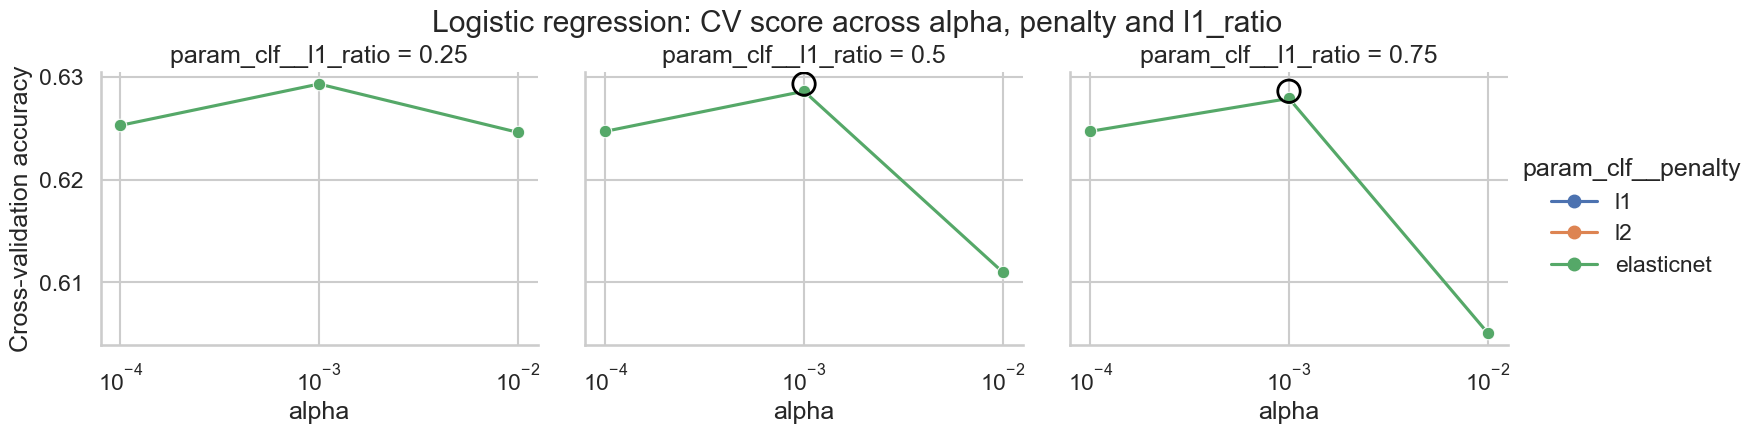

Saved figure to outputs/figures/ml_hp_logistic_regression.png


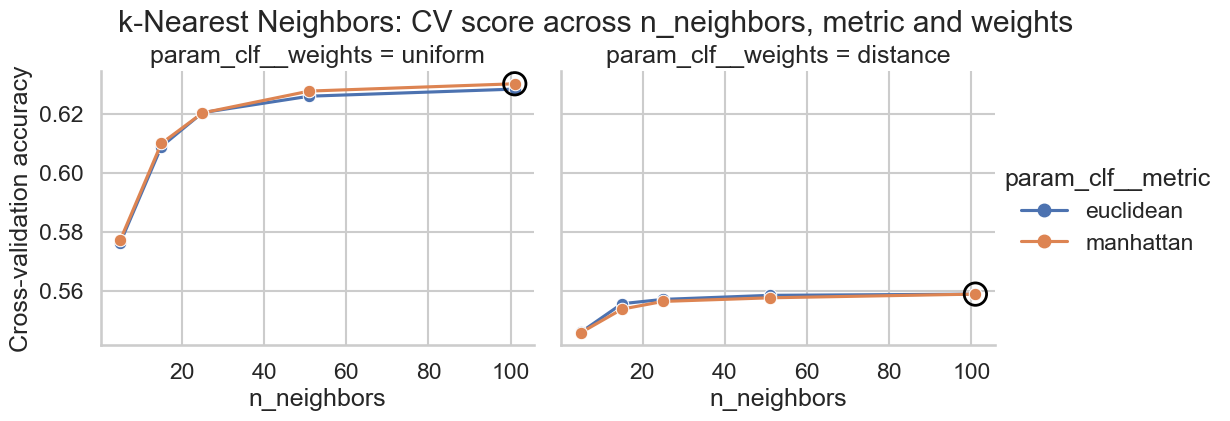

Saved figure to outputs/figures/ml_hp_knn.png


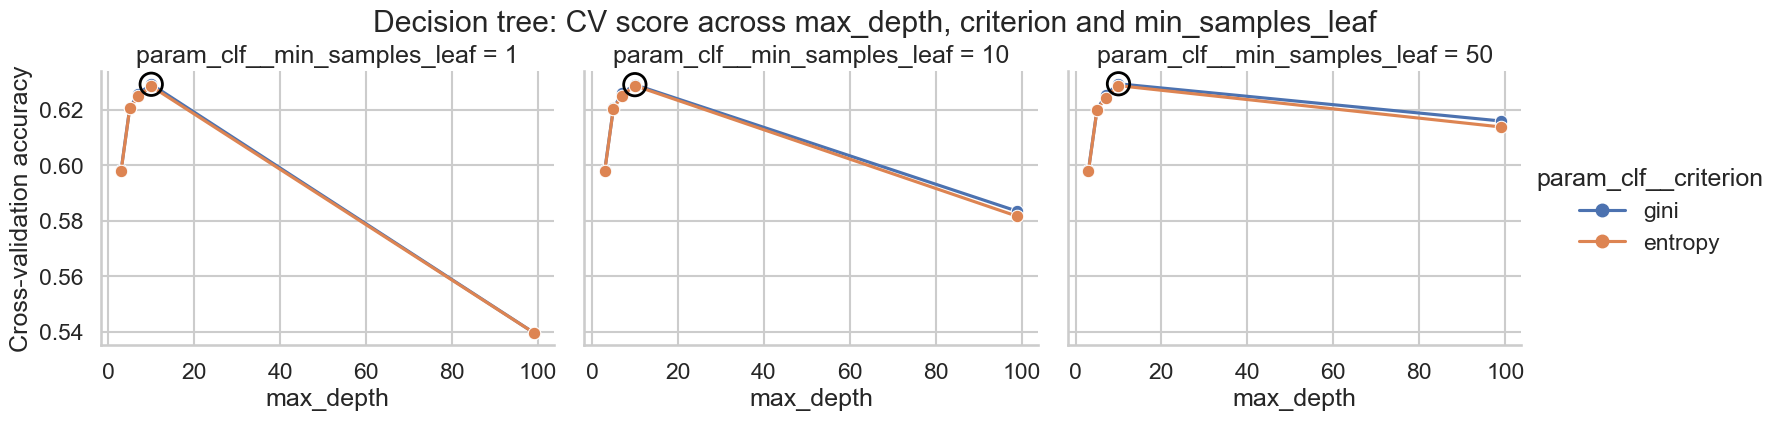

Saved figure to outputs/figures/ml_hp_decision_tree.png


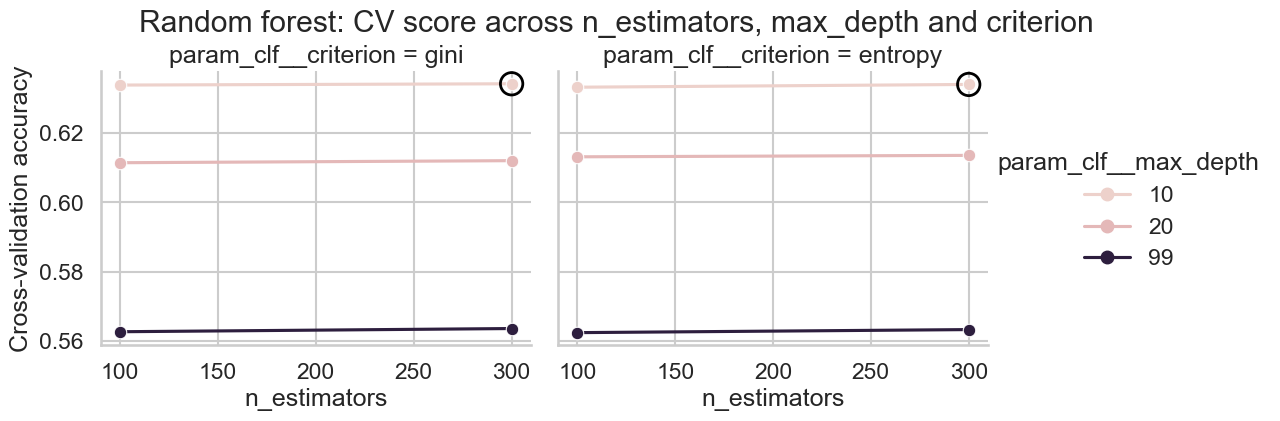

Saved figure to outputs/figures/ml_hp_random_forest.png


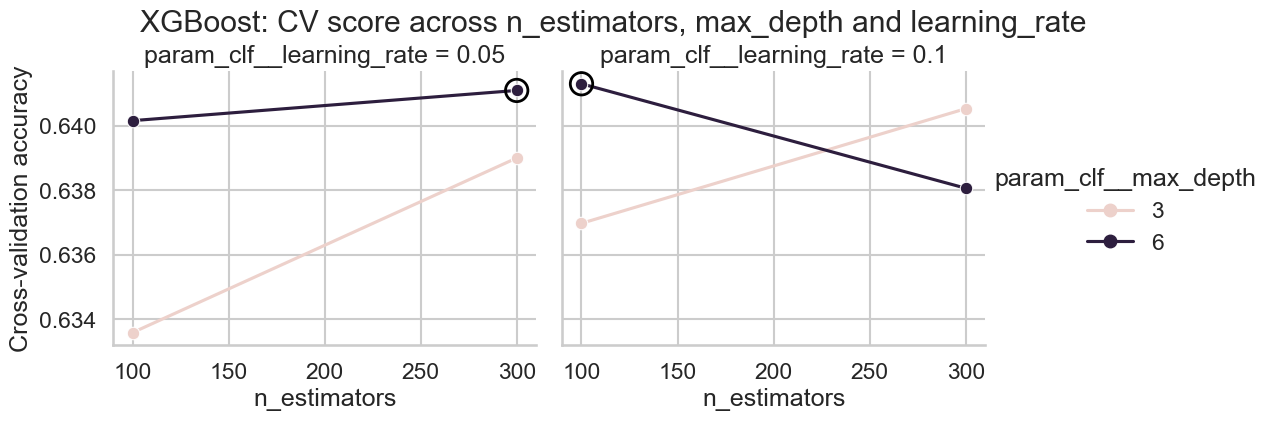

Saved figure to outputs/figures/ml_hp_xgboost.png


PosixPath('/Users/berenaydogan/Documents/4.2/DSA210/Project/DSA210-Project/outputs/figures/ml_hp_xgboost.png')

In [18]:
metric_label = TUNING_METRIC_LABEL

plot_hp_grid(
    cv_results_by_model["logistic_regression"],
    primary="param_clf__alpha",
    hue="param_clf__penalty",
    col="param_clf__l1_ratio",
    title="Logistic regression: CV score across alpha, penalty and l1_ratio",
    savepath=FIGURES_DIR / "ml_hp_logistic_regression.png",
    metric_label=metric_label,
    x_log=True,
)

plot_hp_grid(
    cv_results_by_model["knn"],
    primary="param_clf__n_neighbors",
    hue="param_clf__metric",
    col="param_clf__weights",
    title="k-Nearest Neighbors: CV score across n_neighbors, metric and weights",
    savepath=FIGURES_DIR / "ml_hp_knn.png",
    metric_label=metric_label,
)

plot_hp_grid(
    cv_results_by_model["decision_tree"],
    primary="param_clf__max_depth",
    hue="param_clf__criterion",
    col="param_clf__min_samples_leaf",
    title="Decision tree: CV score across max_depth, criterion and min_samples_leaf",
    savepath=FIGURES_DIR / "ml_hp_decision_tree.png",
    metric_label=metric_label,
)

plot_hp_grid(
    cv_results_by_model["random_forest"],
    primary="param_clf__n_estimators",
    hue="param_clf__max_depth",
    col="param_clf__criterion",
    title="Random forest: CV score across n_estimators, max_depth and criterion",
    savepath=FIGURES_DIR / "ml_hp_random_forest.png",
    metric_label=metric_label,
)

plot_hp_grid(
    cv_results_by_model["xgboost"],
    primary="param_clf__n_estimators",
    hue="param_clf__max_depth",
    col="param_clf__learning_rate",
    title="XGBoost: CV score across n_estimators, max_depth and learning_rate",
    savepath=FIGURES_DIR / "ml_hp_xgboost.png",
    metric_label=metric_label,
)

## 4.8 Final evaluation on the test set

This section evaluates each tuned model once on the test set. The metrics table records accuracy, delayed-class precision, delayed-class recall, specificity, delayed-class F1 and ROC-AUC. Confusion matrices are displayed per model to make the error patterns easy to compare, and the ROC overlay puts the probabilistic models on a shared axis.

In [19]:
def specificity_from_confusion(cm: np.ndarray) -> float:
    """Return specificity from a 2x2 confusion matrix.

    Args:
        cm: Confusion matrix produced with "labels=[0, 1]".

    Returns:
        The proportion of negatives correctly classified, or "nan" when no
        negatives are present.
    """
    true_negatives, false_positives, _, _ = cm.ravel()
    denominator = true_negatives + false_positives
    return true_negatives / denominator if denominator > 0 else float("nan")


def evaluate_model(
    name: str,
    model: Pipeline,
    features: pd.DataFrame,
    targets: pd.Series,
) -> dict:
    """Score a fitted classifier on a feature/target pair from the test set.

    Args:
        name: Identifier written into the result row.
        model: Fitted classifier or pipeline.
        features: Test set feature frame.
        targets: Test set targets aligned with "features".

    Returns:
        A dict containing the public metrics ("accuracy",
        "precision_delayed", "recall_delayed", "specificity",
        "f1_delayed", "roc_auc") and private fields prefixed with
        "_" for building figures.
    """
    y_pred = model.predict(features)
    cm = confusion_matrix(targets, y_pred, labels=[0, 1])
    try:
        y_proba = model.predict_proba(features)[:, 1]
        roc_auc_value = float(roc_auc_score(targets, y_proba))
    except Exception:
        # The majority-class baseline produces a degenerate predict_proba; record NaN AUC.
        y_proba = None
        roc_auc_value = float("nan")
    return {
        "model": name,
        "accuracy": float(accuracy_score(targets, y_pred)),
        "precision_delayed": float(
            precision_score(targets, y_pred, pos_label=1, zero_division=0)
        ),
        "recall_delayed": float(
            recall_score(targets, y_pred, pos_label=1, zero_division=0)
        ),
        "specificity": specificity_from_confusion(cm),
        "f1_delayed": float(f1_score(targets, y_pred, pos_label=1, zero_division=0)),
        "roc_auc": roc_auc_value,
        "_cm": cm,
        "_y_pred": y_pred,
        "_y_proba": y_proba,
    }

In [20]:
evaluation_results: dict[str, dict] = {
    name: evaluate_model(name, model, X_test, y_test)
    for name, model in fitted_models.items()
}

metrics_df = pd.DataFrame(
    [
        {key: value for key, value in result.items() if not key.startswith("_")}
        for result in evaluation_results.values()
    ]
)
metrics_path = TABLES_DIR / "ml_model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved test-set metrics to {metrics_path.relative_to(ROOT)}")
display(metrics_df)

Saved test-set metrics to outputs/tables/ml_model_metrics.csv


,model,accuracy,precision_delayed,recall_delayed,specificity,f1_delayed,roc_auc
0,baseline_majority,0.525875,0.000000,0.000000,1.000000,0.000000,0.500000
1,logistic_regression,0.636314,0.612646,0.633418,0.638924,0.622859,0.688054
2,knn,0.638901,0.619513,0.617859,0.657873,0.618685,0.695655
3,decision_tree,0.635268,0.593541,0.732002,0.548053,0.655540,0.682934
4,random_forest,0.637855,0.605236,0.679169,0.600607,0.640074,0.689940
5,xgboost,0.647655,0.619671,0.665002,0.632014,0.641537,0.709646


Saved figure to outputs/figures/ml_confusion_matrices.png


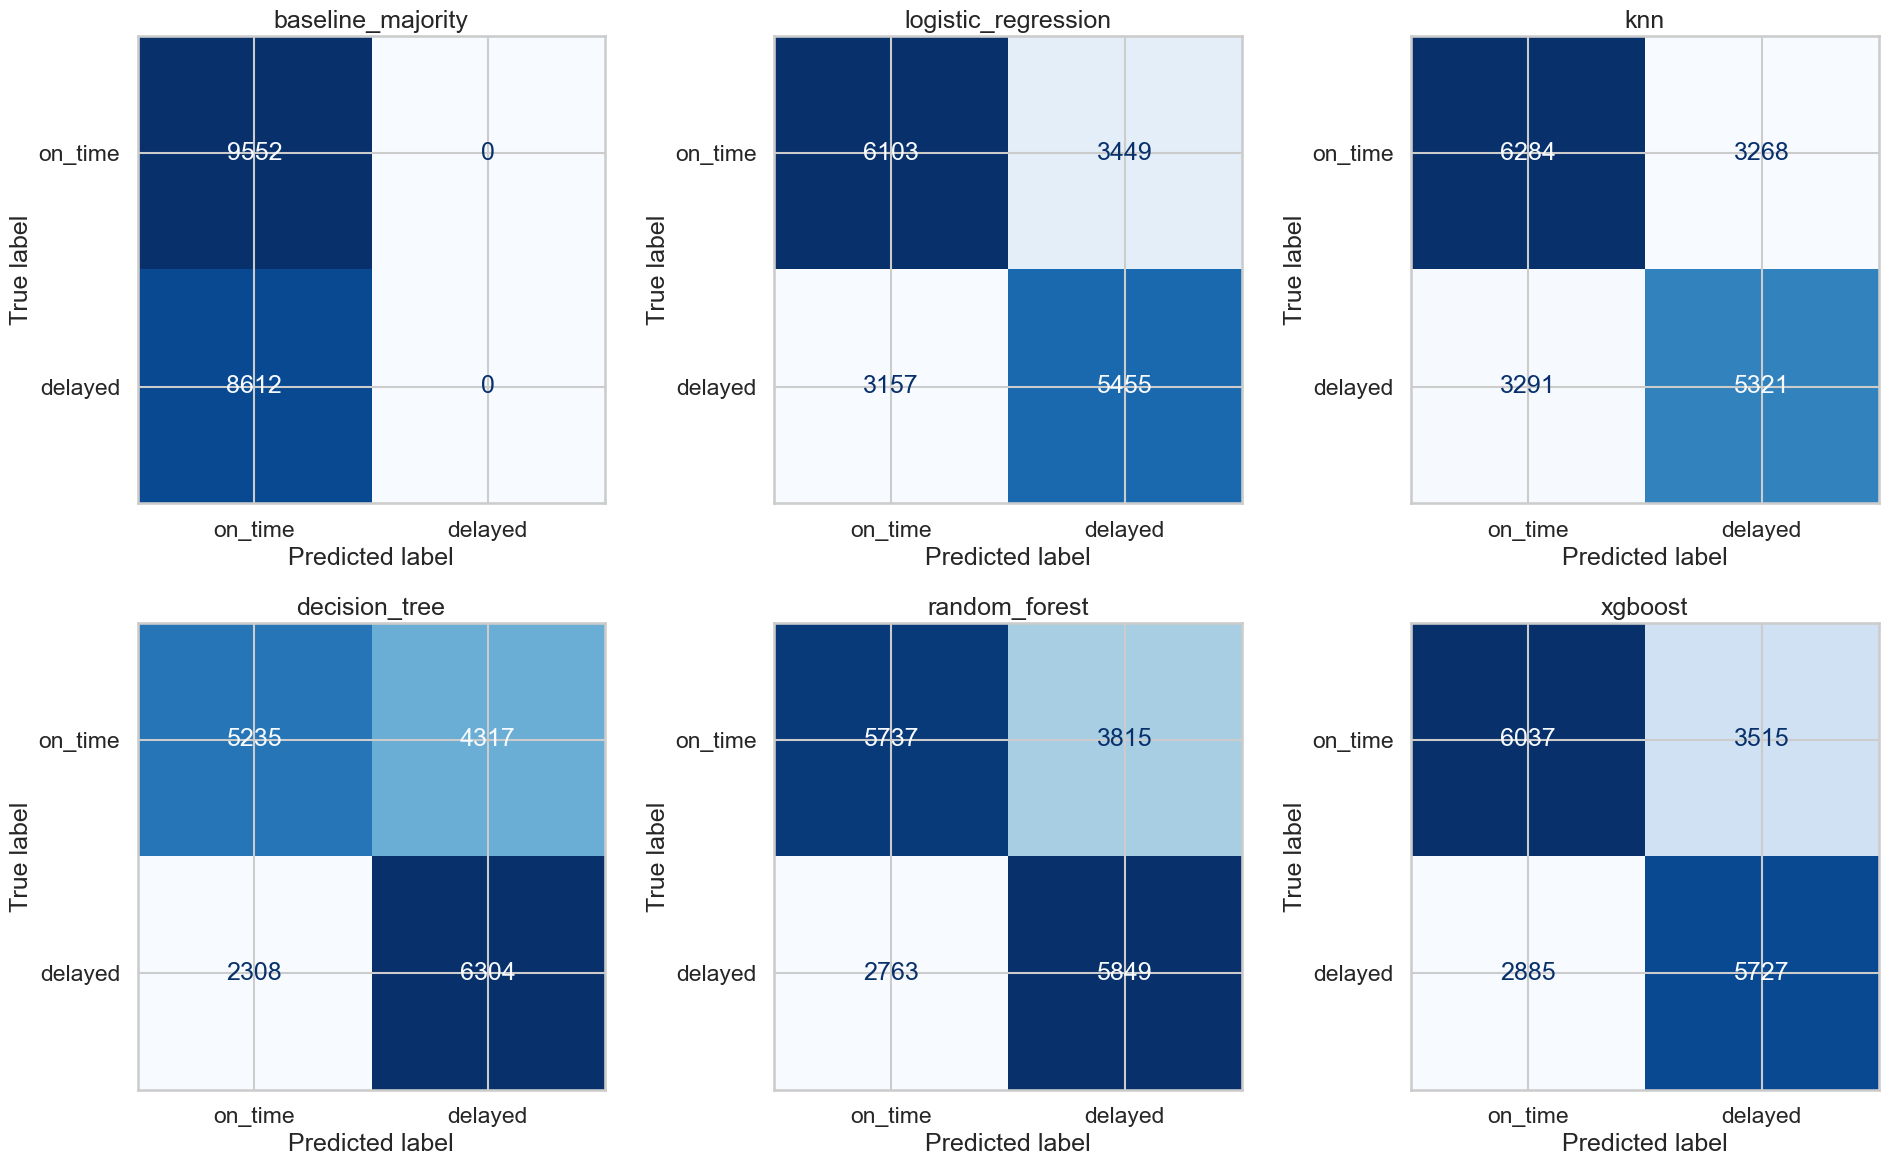

In [21]:
# Confusion matrices per model, in the order they appear in MODEL_SPECS.
model_order = [spec["name"] for spec in MODEL_SPECS]
n_cols = 3
n_rows = int(np.ceil(len(model_order) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows))
axes = np.atleast_1d(axes).ravel()
for ax, model_name in zip(axes, model_order):
    result = evaluation_results[model_name]
    ConfusionMatrixDisplay(
        confusion_matrix=result["_cm"],
        display_labels=["on_time", "delayed"],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(model_name)
for unused_ax in axes[len(model_order):]:
    unused_ax.axis("off")
fig.tight_layout()
confusion_path = FIGURES_DIR / "ml_confusion_matrices.png"
fig.savefig(confusion_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {confusion_path.relative_to(ROOT)}")
plt.show()

Saved figure to outputs/figures/ml_roc_curves.png


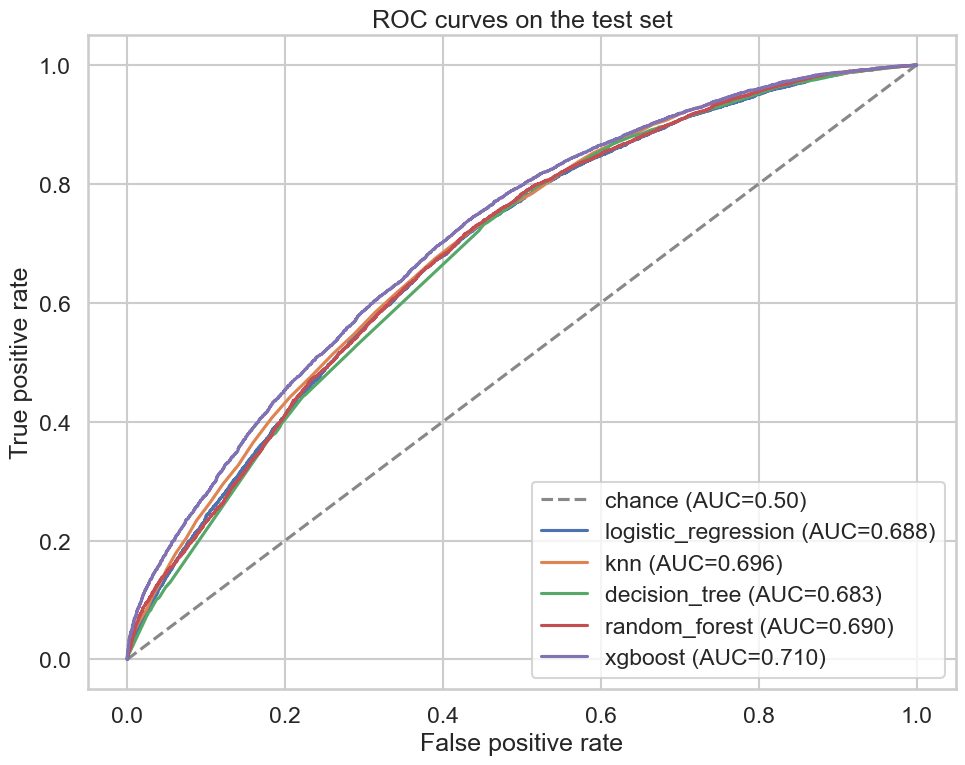

In [22]:
# ROC overlay, skip the baseline because most_frequent gives a degenerate predict_proba.
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], linestyle="--", color="#888888", label="chance (AUC=0.50)")
for model_name in model_order:
    if model_name == "baseline_majority":
        continue
    result = evaluation_results[model_name]
    if result["_y_proba"] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, result["_y_proba"])
    auc_value = result["roc_auc"]
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the test set")
ax.legend(loc="lower right")
fig.tight_layout()
roc_path = FIGURES_DIR / "ml_roc_curves.png"
fig.savefig(roc_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {roc_path.relative_to(ROOT)}")
plt.show()

Each tuned model lifts both delayed-class F1 and ROC-AUC above the majority-class baseline. 